# Netflix Data Analysis


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

**Observation**

This DataFrame contains,

8807 ---> rows

12 ---> columns

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

UNDERSTANDING THE DATA

show_id ---> id 

type ---> content type (Movie / TV Show)

title ---> name of the movie or TV show

director ---> director name 

cast ---> actors and actresses 

country ---> country where the movie was made

date_added ---> date when it was added to Netflix

release_year ---> release year

rating ---> age group who can watch

Rating	Meaning

            G - Suitable for all ages

            PG - Parental guidance suggested

            PG-13 - Parents strongly cautioned for children under 13

            R - Restricted for younger audiences

            TV-Y - Suitable for all children

            TV-14 - Suitable for viewers above 14

            TV-MA - Mature audience only (18+)

duration ---> movie duration in minutes or seasons

listed_in ---> genre

description ---> short summary of the content

Here relese_yesr is integer datatype and everything else is string datatype

## Data cleaning

1, Check for duplicates and handle them

In [6]:

df.duplicated().any()

np.False_

**Observation**

There is no duplicates present in this dataset so no need to handle it

2, Check for missing values and handling them

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


**Obsevation**

From the above output its clear that, this dataset contains missing values

Columns that contains missing values are,

director ---> 6173

cast     ---> 7982

country  ---> 7976 

date_added  ---> 8797 

rating    --->  8803

duration  --->  8804

So we need to handle them...

### Handling missing values

In [8]:
# Fill missing director and cast with 'Unknown'

df['director'] = df['director'].fillna('Unknown')

In [9]:
df['cast'] = df['cast'].fillna('Unknown')

In [10]:
# Fill missing country with mode

df['country'] = df['country'].fillna(df['country'].mode()[0])

In [11]:
# Fill missing rating with mode
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])


In [12]:
# Fill missing duration with mode
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])


In [13]:
# Remove rows with missing rating

df = df.dropna(subset=['rating'])

In [14]:
df = df.dropna(subset=['date_added'])

In [15]:
# checking if we handled all null values

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


**Observation**

All the missing values are handled successfully

3, check for invalid data types and handle them

In [16]:
print(df.dtypes)

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


**Observation**

Most columns are string datatype

release_year is integer datatype

date_added is stored as str datatype instead of datetime and date_added column contained extra spaces in some rows

Hence we need to remove spaces

date_added should be converted into datetime datatypebecause it represents date values

In [17]:
# removing extra spaces

df['date_added'] = df['date_added'].str.strip()

In [18]:
# converting into datetime datatype

df['date_added'] = pd.to_datetime(df['date_added'])
print(df.dtypes)

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object


**Observation**

>Now all columns are having valid data type

>missing values are filled

## Data Transformation / Feature Engineering

In [19]:
# Extract year and month from  date_added

df['year_added'] = df['date_added'].dt.year
print(df[['date_added','year_added']].head())



  date_added  year_added
0 2021-09-25        2021
1 2021-09-24        2021
2 2021-09-24        2021
3 2021-09-24        2021
4 2021-09-24        2021


In [20]:
df['month_added'] = df['date_added'].dt.month
print(df[['date_added','month_added']].head())

  date_added  month_added
0 2021-09-25            9
1 2021-09-24            9
2 2021-09-24            9
3 2021-09-24            9
4 2021-09-24            9


The duration column contains,
90 min,
1 Season,
2 Seasons,
we are classifying it....

In [21]:
df['duration_category'] = df['duration'].apply(
    lambda x: 'Movie Duration' if 'min' in x else 'TV Show Duration'
)
print(df[['duration','duration_category']].head())

    duration duration_category
0     90 min    Movie Duration
1  2 Seasons  TV Show Duration
2   1 Season  TV Show Duration
3   1 Season  TV Show Duration
4  2 Seasons  TV Show Duration


In [22]:
# creating content category

df['content_category'] = df['type'].replace({
    'Movie':'Film Content',
    'TV Show':'Series Content'
    })
print(df[['type','content_category']].head())

      type content_category
0    Movie     Film Content
1  TV Show   Series Content
2  TV Show   Series Content
3  TV Show   Series Content
4  TV Show   Series Content


In [23]:
#listed_in contains multiple genres
# Drama, International Movies
# We can count them.

df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))
print(df[['listed_in','genre_count']].head())


                                           listed_in  genre_count
0                                      Documentaries            1
1    International TV Shows, TV Dramas, TV Mysteries            3
2  Crime TV Shows, International TV Shows, TV Act...            3
3                             Docuseries, Reality TV            2
4  International TV Shows, Romantic TV Shows, TV ...            3


genre_count column was created
to identify content with multiple genres

In [24]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_category,content_category,genre_count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Movie Duration,Film Content,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Show Duration,Series Content,3


**Observation**

 New columns such as:

 year_added

 month_added

 duration_category

 content_category
 
 genre_count are created.

## Data Analysis

1,Movies vs TV Shows

In [25]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

**Observation**

the movies is more that Tv shows in the dataset

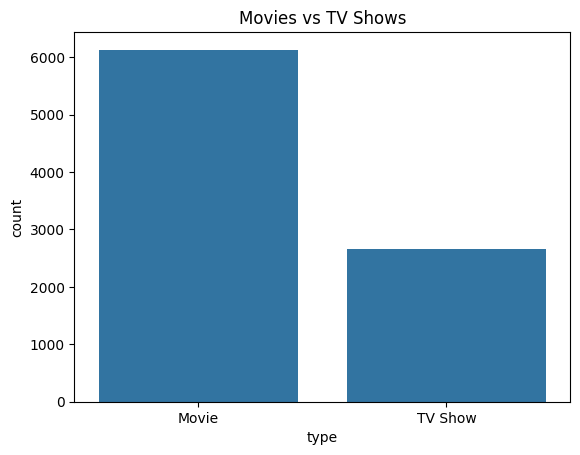

In [26]:
sns.countplot(x='type',data=df)
plt.title("Movies vs TV Shows")
plt.show()

**Observation**

the movies is more that Tv shows in the dataset and that is visualizes using count plot

2,Top 10 Content Producing Countries

In [27]:
df['country'].value_counts().head(10)

country
United States     3642
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

**Observation**

Most of the content are produced by US is 3642 ,The least is Egypt with 106

3,Content Added Year-wise

In [28]:
df['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

**Observation**

More contents are added after 2017

least content was add in the uear 2010

Most content added in the year of 2019

4,Most Common Ratings

In [29]:
df['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

**Observation**

Most common rating are given by marure adults is 3209

most least was Nc-17 and UR

This indicates that a large portion of Netflix's content is intended for mature audiences.

5,Most Popular Genres

In [30]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

**Observation**

Most popular genre is dramas and international movies -->362


In [31]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'duration_category', 'content_category',
       'genre_count'],
      dtype='str')

## Data Visualization

How many Movies and TV Shows are available on Netflix?

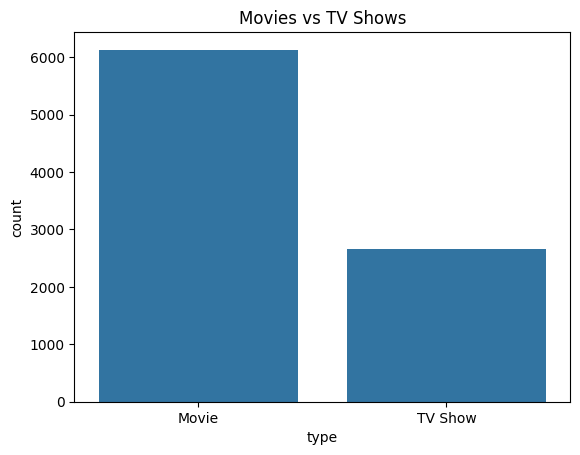

In [32]:
#count plot
sns.countplot(x='type',data=df)
plt.title("Movies vs TV Shows")
plt.show()

**Observation**

Movies availability is higher in netflix

Which are the top 10 countries producing Netflix content?

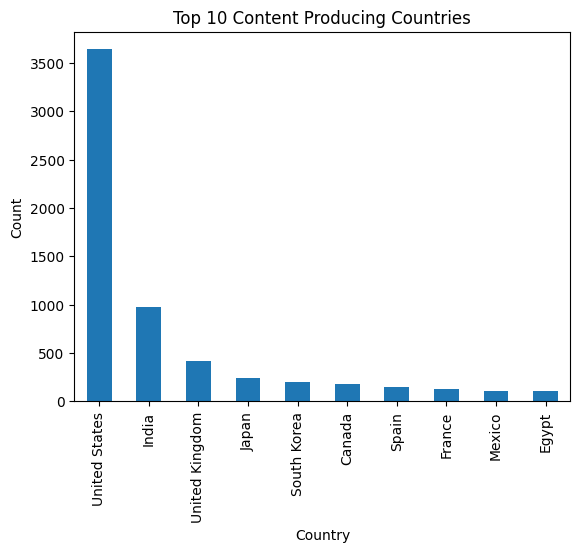

In [33]:
# bar plot

top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

**Observation**

United States produces the highest amount of Netflix content

How has Netflix content grown over the years?

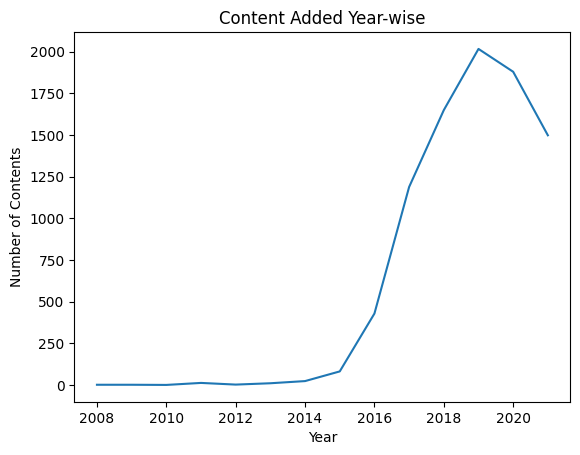

In [34]:
#Line plot

year_data = df['year_added'].value_counts().sort_index()
year_data.plot(kind='line')
plt.title("Content Added Year-wise")
plt.xlabel("Year")
plt.ylabel("Number of Contents")
plt.show()

**Observation**

content additions increased rapidly after 2015.

Percentage of Movies and TV Shows

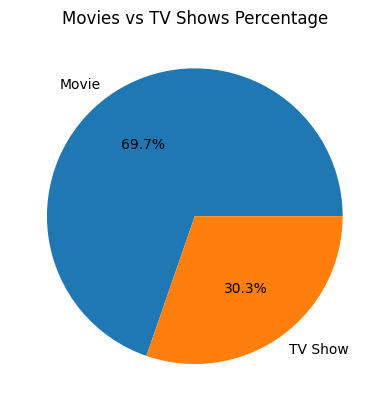

In [35]:
# Pie chart

type_counts = df['type'].value_counts()
plt.pie(type_counts,
        labels=type_counts.index,
        autopct='%1.1f%%')
plt.title("Movies vs TV Shows Percentage")
plt.show()

**Observation**

Movies percentage is higher than TV shows

Distribution of Release Years

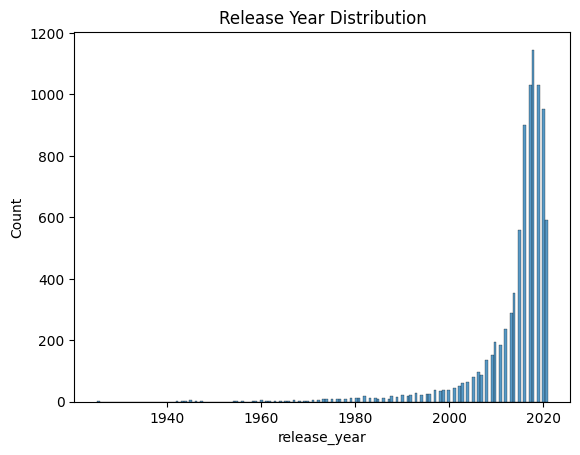

In [36]:
# hist plot

sns.histplot(df['release_year'])
plt.title("Release Year Distribution")
plt.show()

**Observation**

 Most Netflix content was released in recent years.
 
 Older content appears less frequently in the dataset.

Density of Release Years

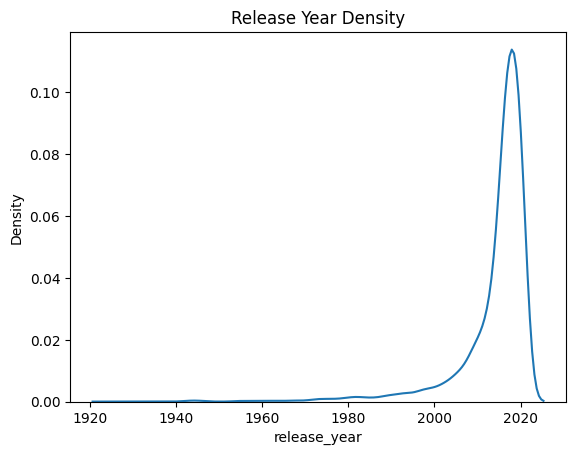

In [37]:
#kde plot

sns.kdeplot(df['release_year'])
plt.title("Release Year Density")
plt.show()

**Observation**

 Netflix mainly focuses on newer content

Movies and TV Shows Added Year-wise

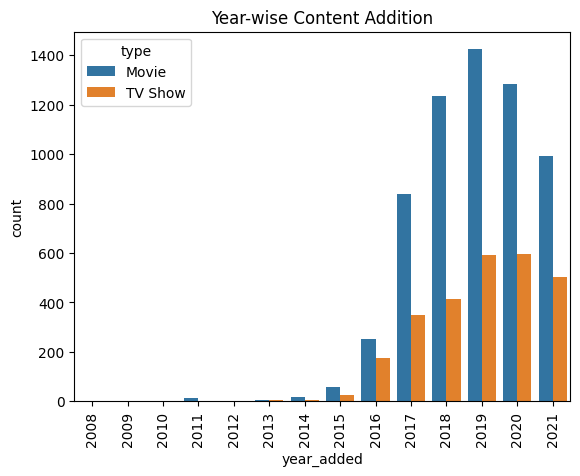

In [38]:
#Hue parameter
sns.countplot(x='year_added',
              data=df,
              hue='type')
plt.xticks(rotation=90)
plt.title("Year-wise Content Addition")
plt.show()

**Observation**

Both Movies addition is more than TV Shows 

Multiple Visualizations Together

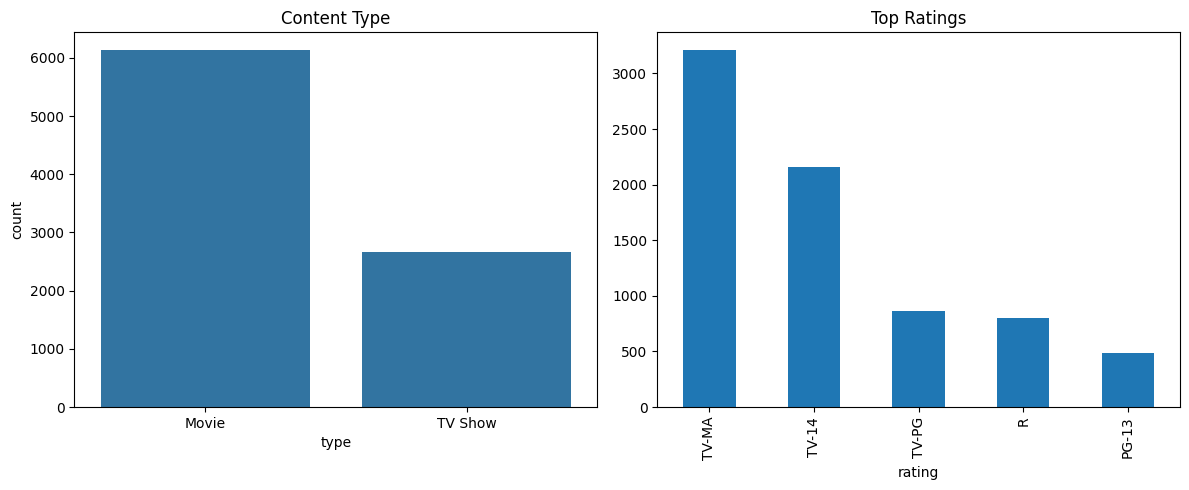

In [39]:
# Sub plots

fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='type',
              data=df,
              ax=axes[0])
axes[0].set_title("Content Type")
df['rating'].value_counts().head(5).plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title("Top Ratings")
plt.tight_layout()
plt.show()

**Observation**

Movies dominate the Netflix platform

Netflix contains a large amount of mature audience content.

Relationship Between Release Year and Genre Count

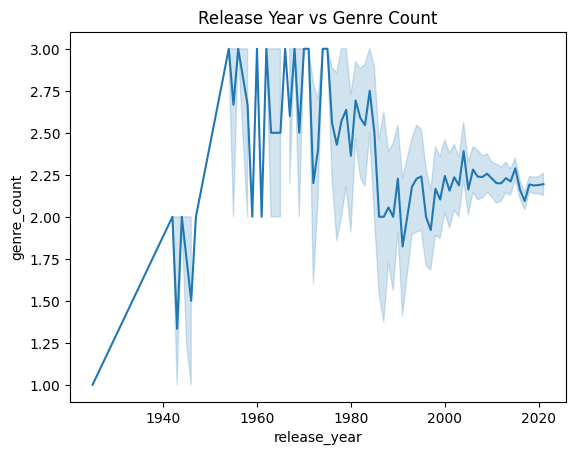

In [40]:
# Bivariate plot

sns.lineplot(x='release_year',
             y='genre_count',
             data=df)

plt.title("Release Year vs Genre Count")

plt.show()

**Observation**

Genre count remains relatively stable across release years

Outlier Detection in Release Years

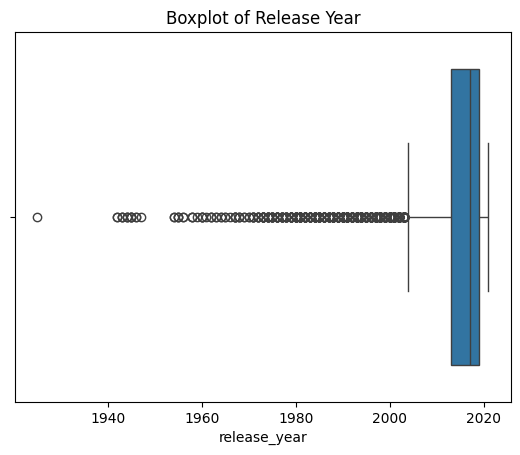

In [41]:
#Box plot
sns.boxplot(x=df['release_year'])
plt.title("Boxplot of Release Year")
plt.show()

**Observation**

The boxplot shows  older content as outliers.

Most content belongs to recent release years.

Correlation Between Numerical Features

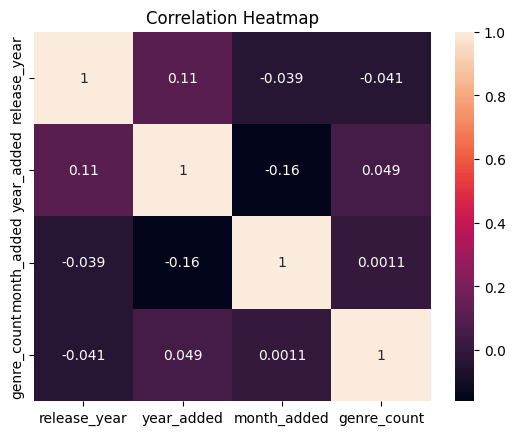

In [42]:
#Heat map
numeric_df = df[['release_year',
                 'year_added',
                 'month_added',
                 'genre_count']]
sns.heatmap(numeric_df.corr(),
            annot=True)
plt.title("Correlation Heatmap")

plt.show()

**Observation**

release_year and year_added show positive correlation.


**Conclusion**

* Since most content is for mature audiences, adding more children's and family-friendly content could help reach a broader audience.

* The platform can continue investing in popular genres such as Drama and International Movies, while also promoting less common genres to provide greater variety.

* As Netflix focuses mainly on recent releases, periodically adding high-quality classic movies and TV shows could appeal to viewers who enjoy older content.

* Netflix can increase content from underrepresented countries to attract more global audience.